/Users/franco/tools/miniconda3/envs/rave/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset length: 49656. Testing new arpeggio and velocity variation features...
Patch: SynthSwell | CHORD min7b5_inv2 rooted at A#3


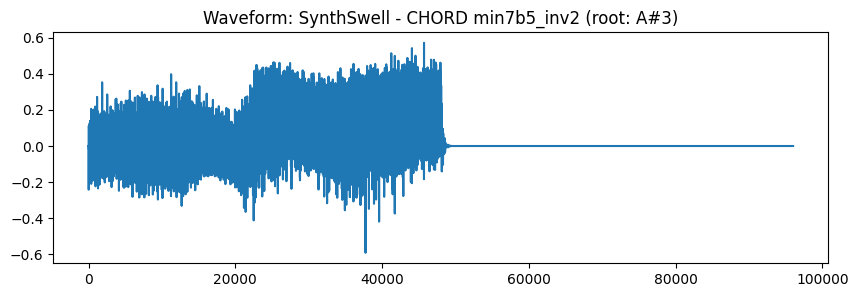

Patch: Bark-Bass  | SINGLE_NOTE rooted at B2


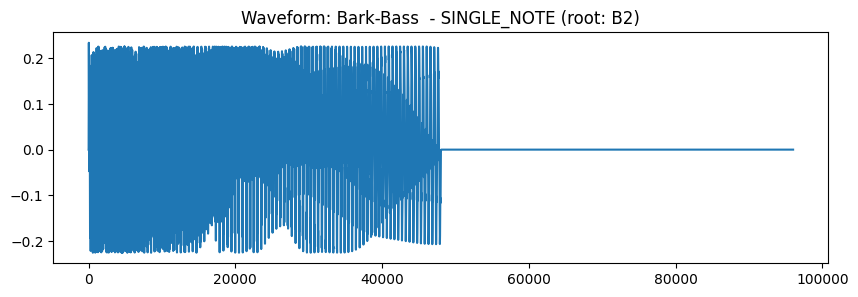

Patch: SYNTHSTRG1 | CHORD min9_inv2 rooted at F#3


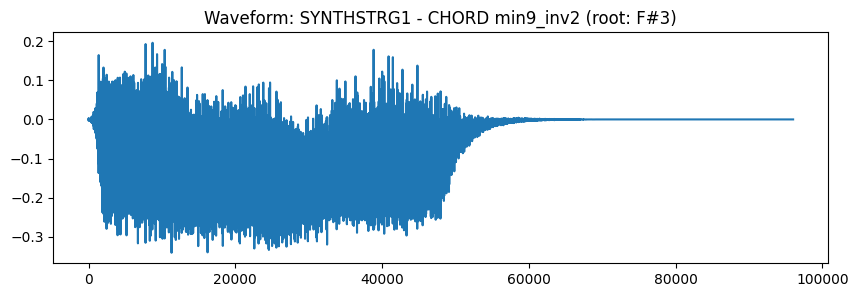

Patch: -ANALOG 4- | SINGLE_NOTE rooted at D#2


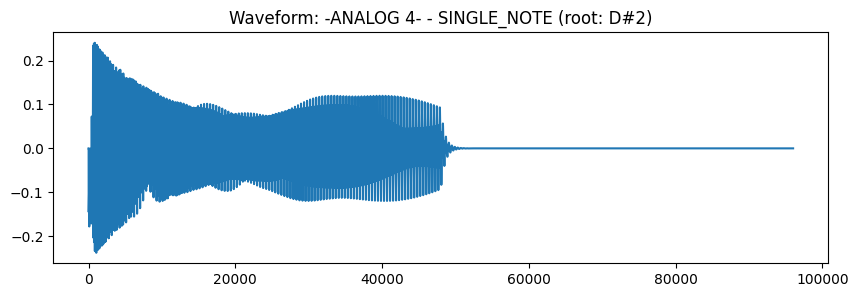

Patch: TOUCHPIANO | ARPEGGIO dim7_inv3 rooted at C#3


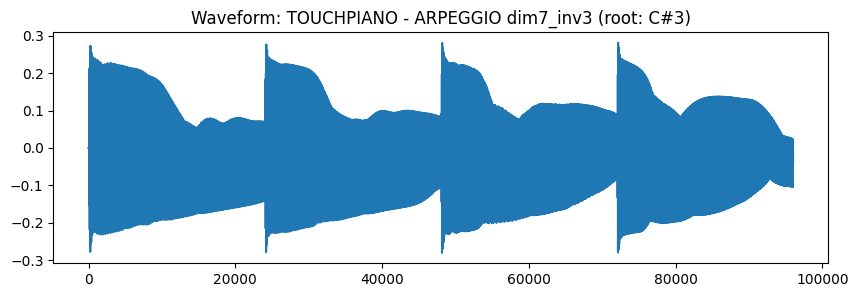

Patch: SYN BRS 3B | CHORD min7b5_inv3 rooted at F2


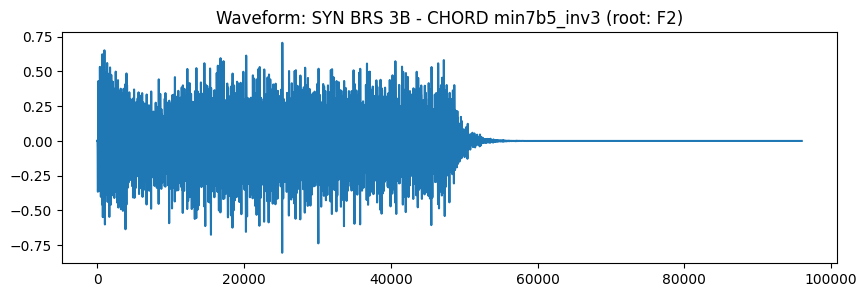

Patch: TytPhaz/+\ | SINGLE_NOTE rooted at A3


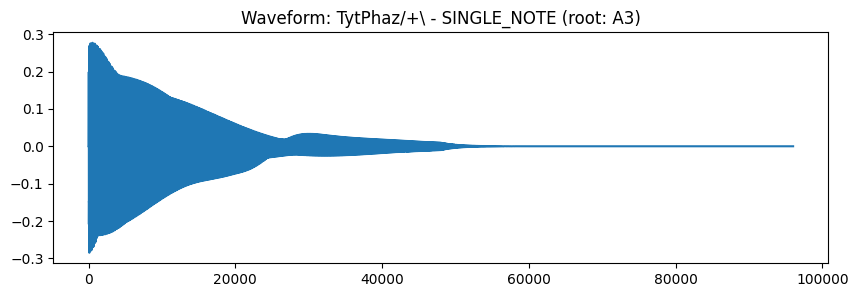

Patch: DreamySyn  | ARPEGGIO maj rooted at F3


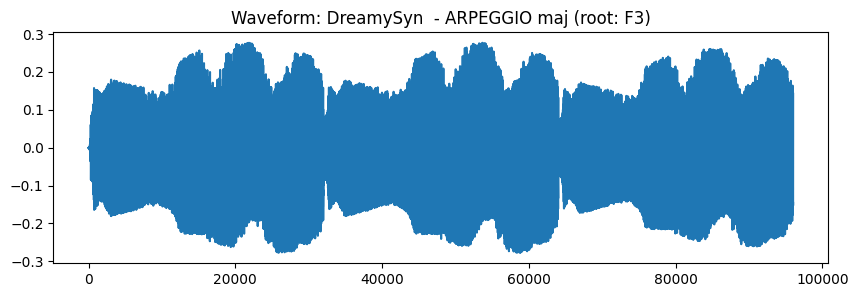

Patch: StrawBerry | ARPEGGIO maj7_inv2 rooted at E3


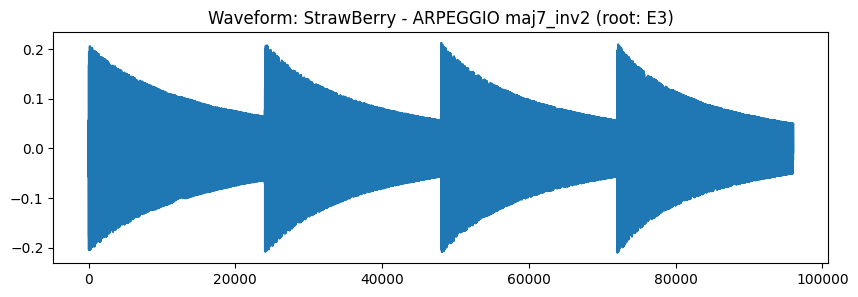

Patch: WitchaTaw  | SINGLE_NOTE rooted at F#2


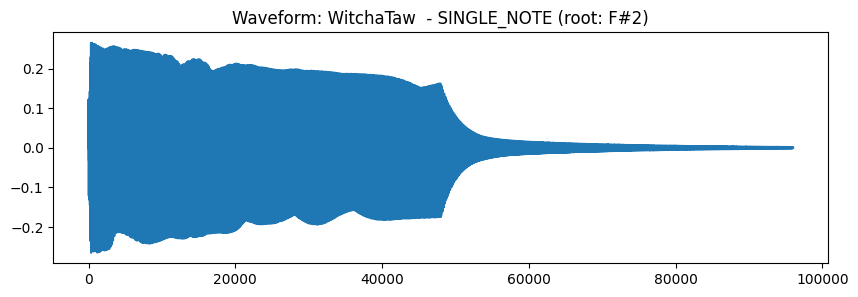

Patch: -=]V[=- 26 | ARPEGGIO sus4_inv2 rooted at A2


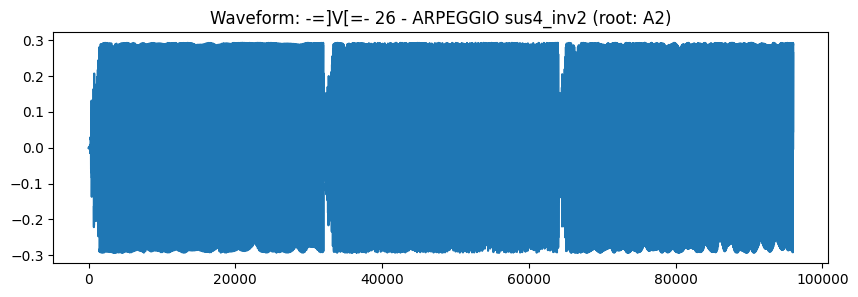

Patch: ClloHrpsTn | CHORD dom7_inv3 rooted at D3


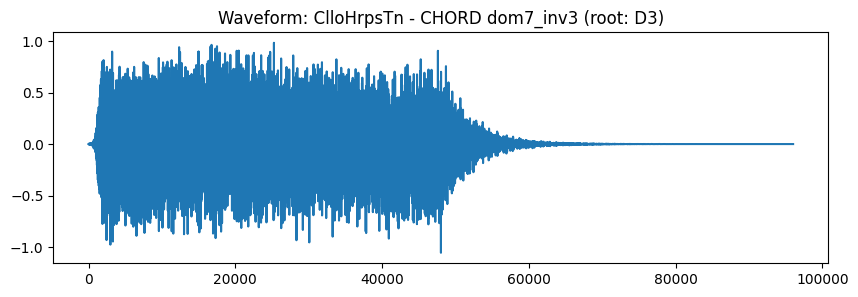

Patch: Cello's.24 | SINGLE_NOTE rooted at A#3


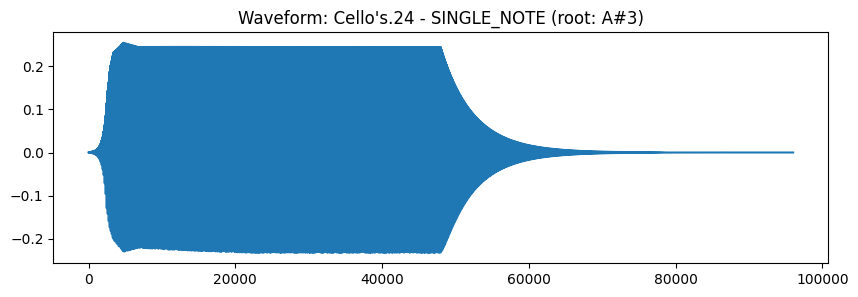

Patch: fairlight  | SINGLE_NOTE rooted at F#2


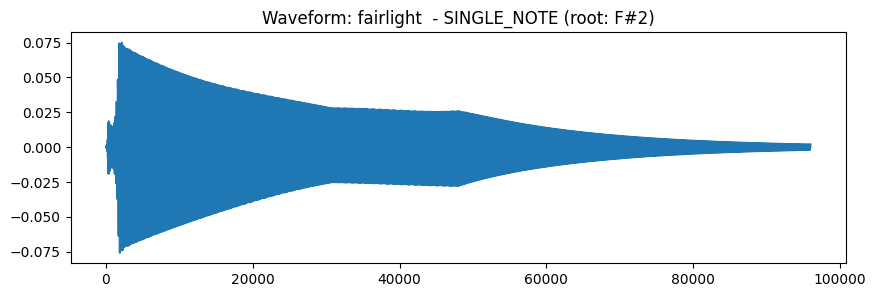

Patch: Eleorgan22 | ARPEGGIO domsharp9 rooted at A3


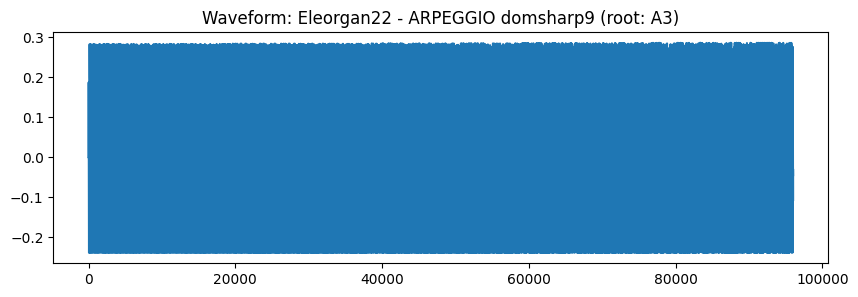

Patch: *Floating  | SINGLE_NOTE rooted at D#3


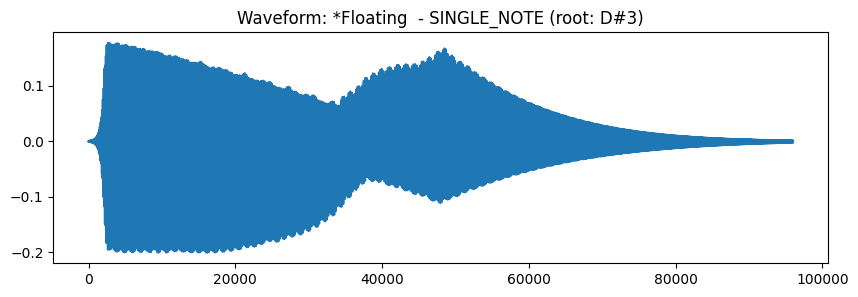

Patch: OBX Horn2  | CHORD min9_inv4 rooted at D3


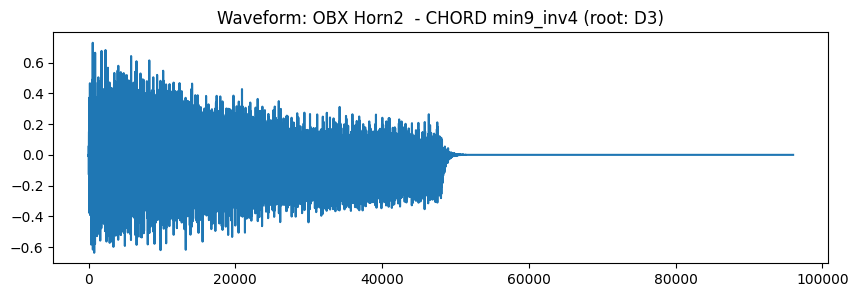

Patch: Big SweepB | ARPEGGIO sus4_inv1 rooted at A#2


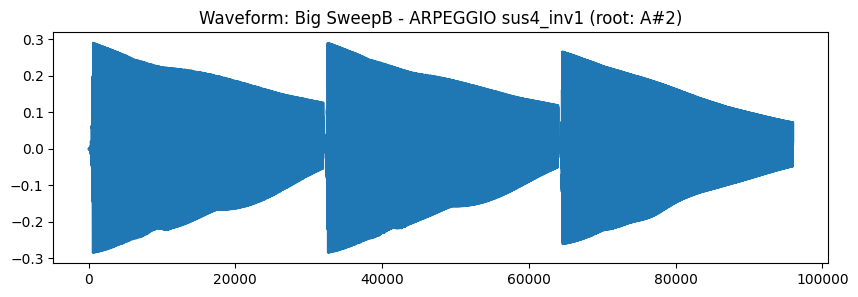

Patch: Piano.083  | SINGLE_NOTE rooted at D2


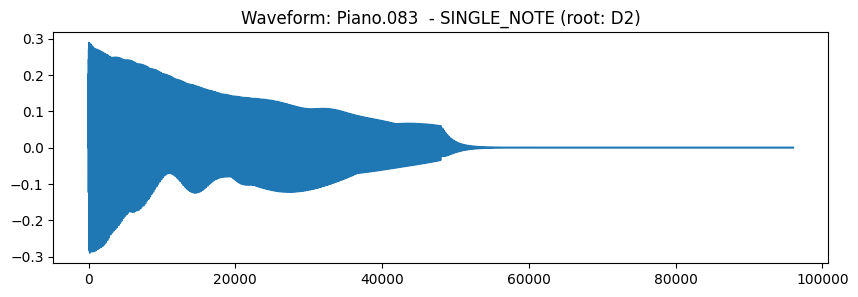

Patch: EleOrgan16 | CHORD dom7 rooted at A#2


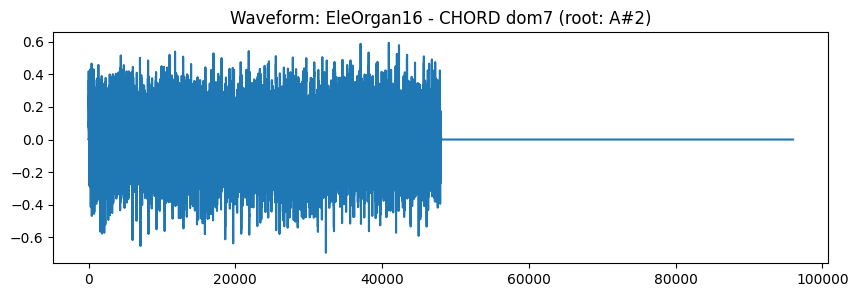

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from dx7pytorch.filters import filter_operator_frequencies_are_ratio
from IPython.display import Audio, display
from dx7pytorch import DXDataset
import torch.utils.data as data

def midi_to_note(midi_number):
    """convert midi note value to note name (60=C4)"""
    notes = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    octave = (midi_number // 12) - 1
    note = notes[midi_number % 12]
    return f"{note}{octave}"

# --- Dataset setup ---
sr = 48000
collection_path = '../dataset/collection.bin'
BATCH_SIZE = 4
dataset = DXDataset(
    sr,
    collection_path,
    valid_notes=[i for i in range (36,60)], #2 octaves
    valid_velocities=(127,),
    note_on_len=sr,
    note_off_len=sr,
    subsample_ratio=0.1,
    random_seed=1234,
    filter_function=filter_operator_frequencies_are_ratio,
    mode_probabilities=[0.333,0.334,0.333]
)

# Split dataset
n_train_examples = int(len(dataset)*0.7)
n_valid_examples = int(len(dataset)*0.2)
n_test_examples = len(dataset) - n_train_examples - n_valid_examples

train_data, valid_data, test_data = torch.utils.data.random_split(
    dataset, [n_train_examples, n_valid_examples, n_test_examples]
)

train_loader = data.DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)

print(f"Dataset length: {len(dataset)}. Testing new arpeggio and velocity variation features...")

# --- Play a few examples ---
i = 0
for instance in train_loader:
    if i == 5:
        break
    i += 1
    
    for j in range(BATCH_SIZE):
        audio = instance['audio'][j].numpy()
        name = instance['name'][j]
        mode = instance['mode'][j]
        root = instance['note'][j].item()  # Convert tensor to int
        note_name = midi_to_note(root)
        
        # Convert from multi-channel (if stereo) to mono
        if audio.ndim > 1:
            audio = np.mean(audio, axis=0)
        
        #print what's being played
        print(f"Patch: {name} | {mode} rooted at {note_name}")
        
        # plot waveform with better title
        plt.figure(figsize=(10, 3))
        plt.title(f"Waveform: {name} - {mode} (root: {note_name})")
        plt.plot(audio)
        plt.show()
        
        # Play audio in notebook
        display(Audio(audio, rate=sr))